## AGN Project: *Characterization of Galaxies via Optical and Infrared Surveys*

### Notebook Preamble

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['retina']

import scipy as sci
import pandas as pd
import numpy as np
import matplotlib as mpl

preamble = r'''
    \usepackage{amsmath}
    \usepackage{amssymb}
    \usepackage{mathtools}
    
    \usepackage{fontspec}
    \usepackage{unicode-math}
    \setmainfont{TeX Gyre Termes}
    \setmathfont{TeX Gyre Termes Math}
    
    \usepackage{microtype}
    
    \usepackage[
    	locale = US,
    	per-mode = power,
    	print-zero-exponent = true,
    	print-unity-mantissa = false
    ]{siunitx}
    
    \DeclareSIUnit{\year}{yr}
    \DeclareSIUnit{\erg}{erg}
    \DeclareSIUnit{\parsec}{pc}
    \DeclareSIUnit{\solarmass}{\ensuremath{M_\odot}}
'''

mpl.rcParams.update({
    "axes.prop_cycle": "cycler('color', ['firebrick', 'goldenrod', 'olivedrab', 'steelblue'])",

    "backend": 'pgf',
    
    "figure.figsize": [3.25, 2.44],
    "figure.constrained_layout.use": True,
    "font.family": 'serif',
    
    "axes.labelsize": 'small',
    
    "font.size": 10,
    
    "legend.fontsize": 'small',
    "legend.frameon": False,
    "legend.handlelength": 1.5,
    "legend.columnspacing": 1.5,
    "legend.handletextpad": 0.6,
    
    "xtick.labelsize": 'small',
    "xtick.minor.visible": True,
    "xtick.direction": 'in',
    "xtick.top": True,
    "ytick.labelsize": 'small',
    "ytick.minor.visible": True,
    "ytick.direction": 'in',
    "ytick.right": True,
    
    "pgf.rcfonts": False,
    
    "text.usetex": True,
    "pgf.texsystem": 'lualatex',
    "pgf.preamble": preamble
})

import matplotlib.pyplot as plt

from scipy.spatial import distance_matrix

### [SkyServer Query](https://skyserver.sdss.org/dr19/SearchTools/sql)

```sql
SELECT TOP 10000
    g.sii_6717_flux, g.sii_6731_flux, g.nii_6584_flux, g.oi_6300_flux, g.oiii_5007_flux,
    g.h_alpha_flux, g.h_beta_flux,
    g.h_alpha_eqw, g.nii_6584_eqw, g.oiii_sigma,
    w.w1mpro, w.w2mpro, w.w3mpro,
    s.z, s.class, s.subclass, s.bestobjid
FROM SpecObj AS s
    JOIN galSpecLine AS g ON s.specobjid = g.specobjid
    JOIN PhotoTag AS p ON s.bestobjid = p.objid
    OUTER APPLY (   SELECT TOP 1 x.wise_cntr
                    FROM wise_xmatch AS x
                    WHERE p.objid = x.sdss_objid AND x.match_dist < 3
                    ORDER BY x.match_dist ASC
                ) AS y
    LEFT JOIN wise_allsky AS w ON y.wise_cntr = w.cntr
WHERE s.class = 'GALAXY'
    AND s.subclass != 'BROADLINE'
    AND s.subclass != 'AGN BROADLINE'
    AND s.subclass != 'STARFORMING BROADLINE'
    AND s.subclass != 'STARBURST BROADLINE'
    AND s.snmedian_r > 5.0
    AND s.z < 0.35
    AND g.sii_6717_eqw < 0
    AND g.sii_6731_eqw < 0
    AND g.nii_6584_eqw < 0
    AND g.oi_6300_eqw < 0
    AND g.oiii_5007_eqw < 0
    AND g.h_alpha_eqw < 0
    AND g.h_beta_eqw < 0
    AND (2.355 * g.sigma_forbidden) < 500
    AND (2.355 * g.sigma_balmer) < 500
    AND g.sii_6717_flux > 3 * g.sii_6717_flux_err
    AND g.sii_6731_flux > 3 * g.sii_6731_flux_err
    AND g.nii_6584_flux > 3 * g.nii_6584_flux_err
    AND g.oi_6300_flux > 3 * g.oi_6300_flux_err
    AND g.oiii_5007_flux > 3 * g.oiii_5007_flux_err
    AND g.h_alpha_flux > 3 * g.h_alpha_flux_err
    AND g.h_beta_flux > 3 * g.h_beta_flux_err
ORDER BY s.specobjid ASC
```

### Dataframe Loading

In [2]:
df = pd.read_csv('data.csv', skiprows=1)

counts = df['bestobjid'].value_counts()

print(f'\nFound a Total of {len(df)} SDSS Objects, with {len(df.dropna(subset=['w1mpro', 'w2mpro', 'w3mpro']))} Matches to the WISE Database.',
      f'There are {len(counts[counts > 1])} Duplicates in this Table.\n',
      f'\nIncluded GALAXY Subclasses: {' '.join(map(str, df['subclass'].dropna().unique()))}\n')

df.head(15).style.hide()


Found a Total of 10000 SDSS Objects, with 9799 Matches to the WISE Database. There are 0 Duplicates in this Table.
 
Included GALAXY Subclasses: STARFORMING STARBURST AGN



sii_6717_flux,sii_6731_flux,nii_6584_flux,oi_6300_flux,oiii_5007_flux,h_alpha_flux,h_beta_flux,h_alpha_eqw,nii_6584_eqw,oiii_sigma,w1mpro,w2mpro,w3mpro,z,class,subclass,bestobjid
35.334970,21.657780,51.591550,8.490424,21.444370,99.400050,25.640470,-5.130115,-2.528958,182.796000,13.538000,13.469000,11.074000,0.064656,GALAXY,STARFORMING,1237650795146445031
30.269960,25.722970,25.789630,6.269853,35.466710,127.305800,38.332260,-21.187690,-3.849116,5.724757,15.291000,15.156000,12.344000,0.052654,GALAXY,STARFORMING,1237648720142401670
36.779390,37.110670,58.870900,12.491980,20.207150,77.048040,22.933670,-4.769841,-3.612301,326.581400,13.812000,13.572000,11.127000,0.134680,GALAXY,STARFORMING,1237650795683512507
80.135600,70.843640,367.876300,19.599120,55.355480,510.664700,91.710970,-15.408550,-10.877340,88.712100,12.901000,12.695000,8.763000,0.048086,GALAXY,STARFORMING,1237650796220514489
48.689910,36.945600,147.909000,7.274137,18.083990,351.304500,66.982060,-22.022530,-9.346472,101.350100,13.149000,12.906000,9.260000,0.065183,GALAXY,STARFORMING,1237648720142336237
194.402200,153.680800,563.458600,32.057770,95.847920,1151.211000,257.940900,-38.925330,-18.940330,127.924000,13.091000,12.818000,9.317000,0.064902,GALAXY,STARFORMING,1237648720142336185
140.534800,110.589700,384.858900,30.056240,203.211000,919.356400,194.093000,-59.879910,-25.235250,133.140200,14.109000,13.638000,9.283000,0.114679,GALAXY,nan,1237650795146379447
31.040920,17.307790,56.051570,6.340064,10.572200,144.651800,30.730270,-8.484818,-3.203966,71.449490,13.580000,13.449000,10.118000,0.060614,GALAXY,STARFORMING,1237651799621959813
42.041940,28.548300,64.894130,13.768800,46.406440,131.258900,34.240510,-4.757507,-2.194183,113.018400,13.732000,13.769000,10.907000,0.056548,GALAXY,STARFORMING,1237650795683446947
57.435880,40.396540,149.090700,9.482595,16.896020,435.409100,104.516500,-27.603120,-9.634499,95.077220,13.923000,13.717000,9.705000,0.065110,GALAXY,STARFORMING,1237648720679338241


### Derived Values

In [3]:
print(f'\nRatios of SDSS Classes:  SF = {100 * len(df[df['subclass'] == 'STARFORMING']) / len(df):.0f}%  ',
      f'SB = {100 * len(df[df['subclass'] == 'STARBURST']) / len(df):.0f}%  ',
      f'AGN = {100 * len(df[df['subclass'] == 'AGN']) / len(df):.0f}%\n')

df[['oiii_h_beta_ratio', 'nii_h_alpha_ratio', 'w2_w3', 'w1_w2', 'el_gas_dens', 'bh_mass']] = np.nan
df[['bpt_class', 'whan_class', 'color_class']] = None

df['oiii_h_beta_ratio'] = df['oiii_5007_flux'] / df['h_beta_flux']
df['nii_h_alpha_ratio'] = df['nii_6584_flux'] / df['h_alpha_flux']
df['w2_w3'] = df['w2mpro'] - df['w3mpro']
df['w1_w2'] = df['w1mpro'] - df['w2mpro']

def el_gas_dens(flux1, flux2, a = 0.4315, b = 2107.0, c = 627.1, Rmin = 0.4375, Rmax = 1.4484):
    'Estimate Electron / Gas Density Using Line Ratios (Sanders et al. 2016)'
    if flux2 == 0.0:
        return np.nan
    R = flux1 / flux2
    if (R >= Rmin) & (R <= Rmax):
        return (c * R - b * a) / (a - R)
    return np.nan

df['el_gas_dens'] = np.vectorize(el_gas_dens)(df['sii_6717_flux'].values, df['sii_6731_flux'].values)

def bh_mass(s, s0 = 200.0, alpha = 8.13, beta = 4.02):
    'Estimate Black Hole Mass Using Galactic Velocity Dispersion (Tremaine et al. 2002)'
    x = np.log10(s / s0)
    y = alpha + beta * x
    return 10**y

df['bh_mass'] = bh_mass(df['oiii_sigma'])

def kewley_discrim_r(r, a = 0.61, b = -0.47, c = 1.19):
    'Classify Galaxies Using Analytical Line Ratio Relation (Kewley et al. 2001)'
    return 10**(a / (np.log10(r) + b) + c)

def kauffmann_discrim_r(r, a = 0.61, b = -0.05, c = 1.3):
    'Classify Galaxies Using Empirical Line Ratio Relation (Kauffmann et al. 2003)'
    return 10**(a / (np.log10(r) + b) + c)

mask = (df['oiii_h_beta_ratio'] <= kewley_discrim_r(df['nii_h_alpha_ratio'])) & (df['oiii_h_beta_ratio'] >= kauffmann_discrim_r(df['nii_h_alpha_ratio']))
df.loc[mask, 'bpt_class'] = 'COMP'

mask = df['oiii_h_beta_ratio'] > kewley_discrim_r(df['nii_h_alpha_ratio'])
df.loc[mask, 'bpt_class'] = 'AGN'

mask = df['oiii_h_beta_ratio'] < kauffmann_discrim_r(df['nii_h_alpha_ratio'])
df.loc[mask, 'bpt_class'] = 'SF'

print(f'Ratios of PBT Classes:   SF = {100 * len(df[df['bpt_class'] == 'SF']) / len(df):.0f}%  ',
      f'COMP = {100 * len(df[df['bpt_class'] == 'COMP']) / len(df):.0f}%  ',
      f'AGN = {100 * len(df[df['bpt_class'] == 'AGN']) / len(df):.0f}%\n')

df.loc[(df['nii_h_alpha_ratio'] < 10**(-0.4)) & (-df['h_alpha_eqw'] > 3.0), 'whan_class'] = 'Pure SF'
df.loc[(df['nii_h_alpha_ratio'] > 10**(-0.4)) & (-df['h_alpha_eqw'] > 6.0), 'whan_class'] = 'Strong AGN'
df.loc[(df['nii_h_alpha_ratio'] > 10**(-0.4)) & (-df['h_alpha_eqw'] < 6.0) & (-df['h_alpha_eqw'] > 3.0), 'whan_class'] = 'Weak AGN'
df.loc[-df['h_alpha_eqw'] < 3.0, 'whan_class'] = 'Radio G'
df.loc[(-df['h_alpha_eqw'] < 0.5) & (-df['nii_6584_eqw'] < 0.5), 'whan_class'] = 'Passive G'

print(f'Ratios of WHAN Classes:  Pure SF = {100 * len(df[df['whan_class'] == 'Pure SF']) / len(df):.0f}%  ',
      f'Strong AGN = {100 * len(df[df['whan_class'] == 'Strong AGN']) / len(df):.0f}%  ',
      f'Weak AGN = {100 * len(df[df['whan_class'] == 'Weak AGN']) / len(df):.0f}%  ',
      f'Radio G = {100 * len(df[df['whan_class'] == 'Radio G']) / len(df):.0f}%  ',
      f'Passive G = {100 * len(df[df['bpt_class'] == 'Passive G']) / len(df):.0f}%\n')

def wedge_up(x, a = 0.315, b = 0.796):
    'Bounds Classification Wedge Upper Border (Mateos et al. 2012)'
    return a * x + b

def wedge_bot(x, a = 0.315, b = -0.222):
    'Bounds Classification Wedge Bottom Border (Mateos et al. 2012)'
    return a * x + b

def wedge_side(x, a = -3.172, b = 7.624):
    'Bounds Classification Wedge Side Border (Mateos et al. 2012)'
    return a * x + b

df.loc[(df['w1_w2'] <= wedge_up(df['w2_w3'])) &
       (df['w1_w2'] >= wedge_bot(df['w2_w3'])) &
       (df['w1_w2'] >= wedge_side(df['w2_w3'])), 'color_class'] = 'AGN'

print(f'Ratio of Color Class:    AGN = {100 * len(df[df['color_class'] == 'AGN']) / len(df):.0f}%\n')

df.head(30).style.hide()


Ratios of SDSS Classes:  SF = 61%   SB = 25%   AGN = 6%

Ratios of PBT Classes:   SF = 77%   COMP = 16%   AGN = 7%

Ratios of WHAN Classes:  Pure SF = 63%   Strong AGN = 31%   Weak AGN = 4%   Radio G = 3%   Passive G = 0%

Ratio of Color Class:    AGN = 1%



sii_6717_flux,sii_6731_flux,nii_6584_flux,oi_6300_flux,oiii_5007_flux,h_alpha_flux,h_beta_flux,h_alpha_eqw,nii_6584_eqw,oiii_sigma,w1mpro,w2mpro,w3mpro,z,class,subclass,bestobjid,oiii_h_beta_ratio,nii_h_alpha_ratio,w2_w3,w1_w2,el_gas_dens,bh_mass,bpt_class,whan_class,color_class
35.334970,21.657780,51.591550,8.490424,21.444370,99.400050,25.640470,-5.130115,-2.528958,182.796000,13.538000,13.469000,11.074000,0.064656,GALAXY,STARFORMING,1237650795146445031,0.836349,0.519029,2.395000,0.069000,nan,93964867.072954,COMP,Weak AGN,None
30.269960,25.722970,25.789630,6.269853,35.466710,127.305800,38.332260,-21.187690,-3.849116,5.724757,15.291000,15.156000,12.344000,0.052654,GALAXY,STARFORMING,1237648720142401670,0.925244,0.202580,2.812000,0.135000,229.742257,84.341785,SF,Pure SF,None
36.779390,37.110670,58.870900,12.491980,20.207150,77.048040,22.933670,-4.769841,-3.612301,326.581400,13.812000,13.572000,11.127000,0.134680,GALAXY,STARFORMING,1237650795683512507,0.881113,0.764080,2.445000,0.240000,514.085576,968512058.233081,COMP,Weak AGN,None
80.135600,70.843640,367.876300,19.599120,55.355480,510.664700,91.710970,-15.408550,-10.877340,88.712100,12.901000,12.695000,8.763000,0.048086,GALAXY,STARFORMING,1237650796220514489,0.603586,0.720387,3.932000,0.206000,285.593960,5137484.383070,COMP,Strong AGN,None
48.689910,36.945600,147.909000,7.274137,18.083990,351.304500,66.982060,-22.022530,-9.346472,101.350100,13.149000,12.906000,9.260000,0.065183,GALAXY,STARFORMING,1237648720142336237,0.269983,0.421028,3.646000,0.243000,93.331438,8775515.289300,SF,Strong AGN,None
194.402200,153.680800,563.458600,32.057770,95.847920,1151.211000,257.940900,-38.925330,-18.940330,127.924000,13.091000,12.818000,9.317000,0.064902,GALAXY,STARFORMING,1237648720142336185,0.371589,0.489449,3.501000,0.273000,139.062989,22377243.149485,SF,Strong AGN,None
140.534800,110.589700,384.858900,30.056240,203.211000,919.356400,194.093000,-59.879910,-25.235250,133.140200,14.109000,13.638000,9.283000,0.114679,GALAXY,nan,1237650795146379447,1.046977,0.418618,4.355000,0.471000,133.765810,26277401.785509,COMP,Strong AGN,None
31.040920,17.307790,56.051570,6.340064,10.572200,144.651800,30.730270,-8.484818,-3.203966,71.449490,13.580000,13.449000,10.118000,0.060614,GALAXY,STARFORMING,1237651799621959813,0.344032,0.387493,3.331000,0.131000,nan,2152464.179537,SF,Pure SF,None
42.041940,28.548300,64.894130,13.768800,46.406440,131.258900,34.240510,-4.757507,-2.194183,113.018400,13.732000,13.769000,10.907000,0.056548,GALAXY,STARFORMING,1237650795683446947,1.355308,0.494398,2.862000,-0.037000,nan,13599377.186197,COMP,Weak AGN,None
57.435880,40.396540,149.090700,9.482595,16.896020,435.409100,104.516500,-27.603120,-9.634499,95.077220,13.923000,13.717000,9.705000,0.065110,GALAXY,STARFORMING,1237648720679338241,0.161659,0.342415,4.012000,0.206000,17.730437,6787765.745866,SF,Pure SF,None


### Plotting

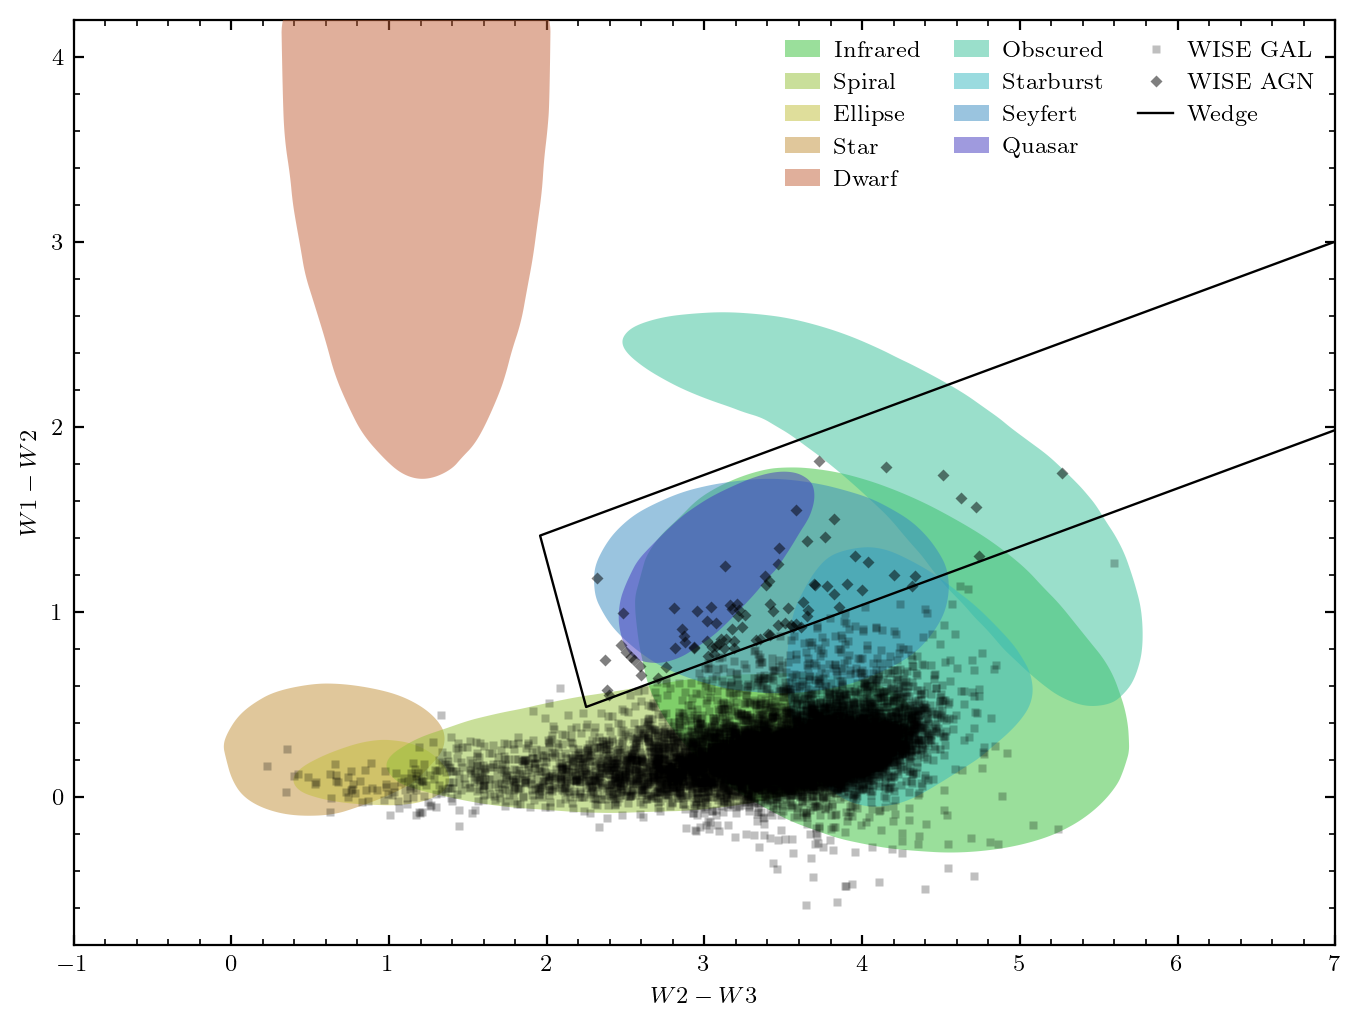

In [4]:
def read_shapes(file_path, refine = 5):
    x, y = np.genfromtxt(file_path, unpack=True, delimiter=',', skip_header=1)
    
    points = np.column_stack((x, y))
    dist_mat = distance_matrix(points, points)
    
    unvisited = list(range(len(points)))
    current = unvisited.pop(0)
    path = [current]
    
    while unvisited:
        nearest = min(unvisited, key=lambda idx: dist_mat[current, idx])
        unvisited.remove(nearest)
        path.append(nearest)
        current = nearest
        
    x = x[path]
    y = y[path]
    
    for _ in range(refine):
        closeX = np.append(x, x[0])
        closeY = np.append(y, y[0])
        newX, newY = [], []
        for i in range(len(closeX) - 1):
            newX.append(0.75 * closeX[i] + 0.25 * closeX[i+1])
            newX.append(0.25 * closeX[i] + 0.75 * closeX[i+1])
            newY.append(0.75 * closeY[i] + 0.25 * closeY[i+1])
            newY.append(0.25 * closeY[i] + 0.75 * closeY[i+1])
        x, y = np.array(newX), np.array(newY)
    return x, y

x1, y1 = read_shapes('assets/shapes/dwarfs.csv')
x2, y2 = read_shapes('assets/shapes/stars.csv')
x3, y3 = read_shapes('assets/shapes/ellipticals.csv')
x4, y4 = read_shapes('assets/shapes/spirals.csv')
x5, y5 = read_shapes('assets/shapes/lirgs.csv')
x6, y6 = read_shapes('assets/shapes/obscureds.csv')
x7, y7 = read_shapes('assets/shapes/starbursts.csv')
x8, y8 = read_shapes('assets/shapes/seyferts.csv')
x9, y9 = read_shapes('assets/shapes/quasars.csv')

plt.figure(figsize=[6.69, 5.02])

a = 0.5

plt.fill(x5, y5, antialiased=True, alpha = a, color='#37c139', label='Infrared', linewidth=0, zorder=50)
plt.fill(x4, y4, antialiased=True, alpha = a, color='#94c137', label='Spiral', linewidth=0, zorder=40)
plt.fill(x3, y3, antialiased=True, alpha = a, color='#c1bf38', label='Ellipse', linewidth=0, zorder=30)
plt.fill(x2, y2, antialiased=True, alpha = a, color='#c29038', label='Star', linewidth=0, zorder=20)
plt.fill(x1, y1, antialiased=True, alpha = a, color='#c26138', label='Dwarf', linewidth=0, zorder=10)
plt.fill(x6, y6, antialiased=True, alpha = a, color='#37c098', label='Obscured', linewidth=0, zorder=60)
plt.fill(x7, y7, antialiased=True, alpha = a, color='#37b9c0', label='Starburst', linewidth=0, zorder=70)
plt.fill(x8, y8, antialiased=True, alpha = a, color='#368ac0', label='Seyfert', linewidth=0, zorder=80)
plt.fill(x9, y9, antialiased=True, alpha = a, color='#4136bf', label='Quasar', linewidth=0, zorder=90)
plt.plot([], [], ' ', label=' ')

x_wedge = [7, 6828/3487, 7846/3487, 7]
y_wedge = [3001/1000, 615809/435875, 212172/435875, 1983/1000]

plt.plot(df['w2_w3'][df['color_class'] != 'AGN'], df['w1_w2'][df['color_class'] != 'AGN'],
         'ks', mec='none', ms=3, alpha=0.25, label=r'$\!\!\!$WISE GAL', zorder=100)
plt.plot(df['w2_w3'][df['color_class'] == 'AGN'], df['w1_w2'][df['color_class'] == 'AGN'],
         'kD', mec='none', ms=3, alpha=0.5, label=r'$\!\!\!$WISE AGN', zorder=100)

plt.plot(x_wedge, y_wedge, 'k-', label='Wedge', lw=0.85, zorder=110)
plt.plot([], [], ' ', label=' ')
plt.plot([], [], ' ', label=' ')

plt.xlim(-1, 7)
plt.ylim(-0.8, 4.2)

plt.xlabel(r'$W2 - W3$')
plt.ylabel(r'$W1 - W2$')

plt.legend(ncols=3)

plt.show()
plt.close()